In [1]:
import sys
sys.path.append("../")

In [2]:
import pandas as pd

from DL_speech_tech import post_analysis, remove_stress_annots, list_pairwise_alignment
from src.audio_processing import read_audio_file
from src.label_data_processing import actor_recordings
from src.PER_Generation import calculate_phoneme_errors

from src.pronunciation_dictionaries import cmu_alphabet
from src.wav2vec2_frame_prediction import Wav2Vec2ForFramePrediction

model = Wav2Vec2ForFramePrediction(cmu_alphabet, w2v2_model_format="onnx")
model.load(name='model_mailabs_equilibrated_pca_95_knn_10_w')

RAM - start of DL_speech_tech: 119.54296875
RAM - DL_speech_tech after external dependencies: 119.8828125
RAM - DL_speech_tech after src.audio_processing: 142.93359375
RAM - text_processing start: 143.0703125
RAM - phonemizer_utils start: 201.23828125
RAM - pronunciation_dictionaries start: 225.53125
RAM - pronunciation_dictionaries after external libraries: 225.53125


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 126052/126052 [00:00<00:00, 906269.50it/s]


RAM - phonemizer_utils after backend dict: 306.4375
RAM - text_processing after external libraries: 306.44140625
RAM - text_processing after g2p model: 371.41796875
RAM - text_processing after lambda functions: 371.41796875
RAM - text_processing after pronunciation_dictionaries: 371.41796875
RAM - text_processing after syllable_processsing: 422.63671875
RAM - text_processing after syllables_df: 512.48828125
RAM - text_processing after all function declarations: 617.94921875
RAM - DL_speech_tech after src.text_processing: 617.953125
RAM - DL_speech_tech after src.pronunciation_dictionaries: 617.953125
RAM - DL_speech_tech after wav2vec2_frame_prediction: 770.33203125
Ignored unknown kwarg option normalize
Ignored unknown kwarg option normalize
Ignored unknown kwarg option normalize
Ignored unknown kwarg option normalize
RAM - DL_speech_tech after default_model: 1176.98828125
Ignored unknown kwarg option normalize
Ignored unknown kwarg option normalize
Ignored unknown kwarg option normal

In [3]:
df = actor_recordings()
df.shape

(4584, 17)

In [4]:
len(df.text.unique())

1031

In [5]:
len(df.audio_file_url.unique())

2746

In [6]:
df.head()

,phrase_id,target_phoneme,target_word_indexes,target_syllable_indexes,phonetic_variant,text,cmu_phonetics,pronounciation_guide,syllable_parts,stress_category,words,syllabified_words,cmu,gibberish,audio_id,audio_file_url,gender
0,mfnhgbvhuf,NaN,NaN,NaN,NaN,Claire didn't buy a *car*,K_L_EH1_R D_IH1|D_AH0_N_T B_AY1 AH0 K_AA1_R,k_l_e_r d_i|d_uh_n_t b_ay uh k_o_r,Claire did|n't buy a car,NaN,"[""Claire"",""didn't"",""buy"",""a"",""*car*""]","[""Claire"",""did|n't"",""buy"",""a"",""car""]","[""K_L_EH1_R"",""D_IH1|D_AH0_N_T"",""B_AY1"",""AH0"",""...","[""k_l_e_r"",""d_i|d_uh_n_t"",""b_ay"",""uh"",""k_o_r""]",claire-car1,data/flwc-phrase-audios/M1/claire-didnt-buy-a-...,MALE
1,evchrfqvna,NaN,NaN,NaN,NaN,Claire didn't *buy* a car,K_L_EH1_R D_IH1|D_AH0_N_T B_AY1 AH0 K_AA1_R,k_l_e_r d_i|d_uh_n_t b_ay uh k_o_r,Claire did|n't buy a car,CORRECTION,"[""Claire"",""didn't"",""*buy*"",""a"",""car""]","[""Claire"",""did|n't"",""buy"",""a"",""car""]","[""K_L_EH1_R"",""D_IH1|D_AH0_N_T"",""B_AY1"",""AH0"",""...","[""k_l_e_r"",""d_i|d_uh_n_t"",""b_ay"",""uh"",""k_o_r""]",claire-buy1,data/flwc-phrase-audios/M1/claire-didnt-buy1-a...,MALE
2,zsjuehxbbn,NaN,[3],NaN,NaN,I study business *and* marketing.,AY1 S_T_AH1|D_IY0 B_IH1|Z_N_AH0_S AH0_N_D M_AA...,ay s_t_uh|d_ee b_i|z_n_uh_s uh_n_d m_o_r|k_uh|...,I stud|y busi|ness and mar|ket|ing,CORRECTION,"[""I"",""study"",""business"",""*and*"",""marketing.""]","[""I"",""stud|y"",""busi|ness"",""and"",""mar|ket|ing""]","[""AY1"",""S_T_AH1|D_IY0"",""B_IH1|Z_N_AH0_S"",""AH0_...","[""ay"",""s_t_uh|d_ee"",""b_i|z_n_uh_s"",""uh_n_d"",""m...",IY2F6ZLOFVDUEX3UGFPTCMA,data/flwc-phrase-audios/F4/zsjuehxbbn__F4_en-G...,FEMALE
3,zsjuehxbbn,NaN,[3],[0],NaN,I study business *and* marketing.,AY1 S_T_AH1|D_IY0 B_IH1|Z_N_AH0_S AH0_N_D M_AA...,ay s_t_uh|d_ee b_i|z_n_uh_s uh_n_d m_o_r|k_uh|...,I stud|y busi|ness and mar|ket|ing,CORRECTION,"[""I"",""study"",""business"",""*and*"",""marketing.""]","[""I"",""stud|y"",""busi|ness"",""and"",""mar|ket|ing""]","[""AY1"",""S_T_AH1|D_IY0"",""B_IH1|Z_N_AH0_S"",""AH0_...","[""ay"",""s_t_uh|d_ee"",""b_i|z_n_uh_s"",""uh_n_d"",""m...",IY2F6ZLOFVDUEX3UGFPTCMA,data/flwc-phrase-audios/F4/zsjuehxbbn__F4_en-G...,FEMALE
4,rkrgvhwtmm,NaN,[1],[0],NaN,"I'll *lock* it in, thank you!",AY1_L L_AA1_K IH1_T IH0_N TH_AE1_NG_K Y_UW1,ay_l l_o_k i_t i_n th_a_ng_k y_oo,I'll lock it in thank you,HIGHLIGHT,"[""I''ll"",""*lock*"",""it"",""in,"",""thank"",""you!""]","[""I''ll"",""lock"",""it"",""in"",""thank"",""you""]","[""AY1_L"",""L_AA1_K"",""IH1_T"",""IH0_N"",""TH_AE1_NG_...","[""ay_l"",""l_o_k"",""i_t"",""i_n"",""th_a_ng_k"",""y_oo""]",IY2F6ZLOFVDUEX3UGFPTCMBQ,data/flwc-phrase-audios/F4/rkrgvhwtmm__F4_en-G...,FEMALE


In [7]:
df = df.groupby("audio_id").first()

In [8]:
import IPython
IPython.display.Audio(df.iloc[1].audio_file_url)

In [9]:
%time
s, fs = read_audio_file(df.iloc[0].audio_file_url, fs=16000)

CPU times: user 1e+03 ns, sys: 1e+03 ns, total: 2 µs
Wall time: 5.96 µs


In [10]:
s.shape

(11904,)

In [11]:
%time
phone_prob_matrix = model.predict_phone_prob_matrix(s, 16000)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.05 µs


In [12]:
phone_prob_matrix.shape

(36, 40)

In [13]:
phone_prob_matrix[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.09406467,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.90593533])

In [14]:
model.id_to_p

{0: 'AA',
 1: 'AE',
 2: 'AH',
 3: 'AO',
 4: 'AW',
 5: 'AY',
 6: 'B',
 7: 'CH',
 8: 'D',
 9: 'DH',
 10: 'EH',
 11: 'ER',
 12: 'EY',
 13: 'F',
 14: 'G',
 15: 'HH',
 16: 'IH',
 17: 'IY',
 18: 'JH',
 19: 'K',
 20: 'L',
 21: 'M',
 22: 'N',
 23: 'NG',
 24: 'OW',
 25: 'OY',
 26: 'P',
 27: 'R',
 28: 'S',
 29: 'SH',
 30: 'T',
 31: 'TH',
 32: 'UH',
 33: 'UW',
 34: 'V',
 35: 'W',
 36: 'Y',
 37: 'Z',
 38: 'ZH',
 39: '[SIL]'}

In [15]:
def get_phone_list(phonetics):
    return sum([p.replace('|', '_').split('_') for p in phonetics.split(' ')], [])

In [16]:
phonetics = get_phone_list(df.iloc[0].cmu_phonetics)

In [17]:
phonetics

['F', 'AE1', 'M', 'AH0', 'L', 'IY0']

In [18]:
len(phonetics)

6

In [19]:
df_segmented_full, per_aligned dtw_cost = post_analysis(
            phone_prob_matrix, phonetics=df.iloc[0].cmu_phonetics, model=model
        )

In [20]:
from g2p_en import G2p
g2p = G2p()

In [21]:
g2p("test IBM")

['T', 'EH1', 'S', 'T', ' ', 'IH1', 'B', 'M']

In [22]:
df_segmented_full

,index,phones,start_idx,end_idx,pred_phones_audio,proba_means,GT_proba,pred_proba,start,end,n_times,n_frames,predicted_phones
0,0,F,2,5,F,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.963189,0.963189,0.04,NaN,1,3,F
1,1,AE,5,13,AE,"[0.1173752826595497, 0.6252995643928255, 0.012...",0.625300,0.625300,0.10,0.10,1,8,AE
2,2,M,13,17,M,"[0.0, 0.04968494635307141, 0.0, 0.0, 0.0243859...",0.873937,0.873937,0.26,0.26,1,4,M
3,3,AH,17,18,AH,"[0.0, 0.0, 0.8078632686425419, 0.0, 0.0, 0.0, ...",0.807863,0.807863,0.34,0.34,1,1,AH
4,4,L,18,22,L,"[0.0, 0.0, 0.023498559652984516, 0.0, 0.0, 0.0...",0.877204,0.877204,0.36,0.36,1,4,L
5,5,IY,22,35,IY,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.014935760502706567...",0.826610,0.826610,0.44,0.44,1,13,IY


In [23]:
phonetics = df.iloc[0].cmu_phonetics
phonetics

'F_AE1|M_AH0|L_IY0'

In [24]:
exp_phones = list(df_segmented_full[df_segmented_full.phones.notna()].phones)
expected = "".join(exp_phones)
expected

'FAEMAHLIY'

In [25]:
pred_phones = list(df_segmented_full[df_segmented_full.predicted_phones.notna()].predicted_phones)
predicted = "".join(pred_phones)
predicted

'FAEMAHLIY'

In [26]:
phoneme_list = remove_stress_annots(get_phone_list(phonetics))
(
    max_posterior_df,
    max_posterior_df_filtered_processed,
    max_posterior_df_filtered_processed_threshed,
) = model.max_posterior_phone_df(phone_prob_matrix, proba_thresh=0.5)

In [27]:
max_posterior_df_filtered_processed_threshed

,phone,n_frames,max_proba,mean_proba
0,F,3,1.000000,0.963189
1,AE,8,1.000000,0.625300
2,M,4,1.000000,0.873937
3,AH,1,0.807863,0.807863
4,L,4,1.000000,0.877204
5,IY,13,1.000000,0.826610


In [28]:
RESA, RESB = list_pairwise_alignment(
        max_posterior_df_filtered_processed_threshed.phone.tolist(), phoneme_list
    )

In [29]:
print(f"pred: {''.join(RESA)}\nexp:  {''.join(RESB)}")

pred: FAEMAHLIY
exp:  FAEMAHLIY


In [30]:
insertions, deletions, substitutions, total_phonemes, per = calculate_phoneme_errors(RESB, RESA)
print(insertions, deletions, substitutions, total_phonemes, per)

0 0 0 6 0.0


In [31]:
insertions, deletions, substitutions, total_phonemes, per = calculate_phoneme_errors(exp_phones, pred_phones)
print(insertions, deletions, substitutions, total_phonemes, per)

0 0 0 6 0.0


In [39]:
from tqdm import tqdm

In [ ]:
from nltk.metrics.distance import edit_distance as levenshtein_distance

In [71]:
def analyze(df):
    data = []
    for i, row in tqdm(df.iterrows()):
        s, fs = read_audio_file(row.audio_file_url, fs=16000)
    
        phone_prob_matrix = model.predict_phone_prob_matrix(s, 16000)
    
        for j, row_other in df.iterrows():
            matches = row_other.cmu_phonetics == row.cmu_phonetics
    
            expected_phoneme_list = remove_stress_annots(get_phone_list(row_other.cmu_phonetics))
        
            (
                max_posterior_df,
                max_posterior_df_filtered_processed,
                max_posterior_df_filtered_processed_threshed,
            ) = model.max_posterior_phone_df(phone_prob_matrix, proba_thresh=0.5)
            pred_phoneme_list = max_posterior_df_filtered_processed_threshed.phone.tolist()

            RESA, RESB = list_pairwise_alignment(pred_phoneme_list, expected_phoneme_list)
    
            n_phones = len(expected_phoneme_list)
            n_words = len(row.text.split(" "))
    
            per_aligned = levenshtein_distance(RESB, RESA) / len(RESB)
            per = levenshtein_distance(expected_phoneme_list, pred_phoneme_list) / len(expected_phoneme_list)
    
            _, dtw_cost = model.phone_prob_matrix_segmentation(
                phone_prob_matrix, expected_phoneme_list
            )
    
            data.append(
                {
                    'per_aligned': per_aligned,
                    'per': per,
                    'dtw_score': -dtw_cost/n_phones if dtw_cost else 0.0,
                    'true_phonetics': row_other.cmu_phonetics,
                    'phonetics': row.cmu_phonetics,
                    'pred_phones': pred_phoneme_list,
                    'n_phones': n_phones,
                    'n_words': n_words,
                    'match': matches,
                }
            )
    
    data = pd.DataFrame(data)
    return data

In [108]:
df_sample = df.sample(200, random_state=0)
data = analyze(df_sample)

0it [00:00, ?it/s]/Users/sebastien.wertz/Documents/Flowchase/flowspeech/notebooks/../src/dtw_forced_aligner.py:280: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_df_full.iloc[start_idx + 1 : end_idx + 1].start = steps
/Users/sebastien.wertz/Documents/Flowchase/flowspeech/notebooks/../src/dtw_forced_aligner.py:281: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_df_full.iloc[start_idx:end_idx].end = steps
/Users/sebastien.wertz/Documents/Flowchase/flowspeech/notebooks/../src/dtw_forced_aligner.py:280: Sett

In [109]:
data.to_parquet("match_mismatch_analysis.pq")

In [110]:
#data = pd.read_parquet("match_mismatch_analysis.pq")

In [111]:
len(data.true_phonetics.unique())

189

In [112]:
data

,error_rate,per_aligned,per,dtw_score,true_phonetics,phonetics,pred_phones,n_phones,n_words,match
0,0.800000,0.555556,0.800000,3.081203,P_IH1|K_AH0_L,P_IH1|K_AH0_L,"[P, HH, IH, K, AO, AA, AO, L]",5,1,True
1,0.750000,0.857143,1.000000,0.798107,D_IH0|V_EH1|L_AH0_P_T,P_IH1|K_AH0_L,"[P, HH, IH, K, AO, AA, AO, L]",8,1,False
2,0.875000,0.933333,1.000000,0.426333,S_EH1|L_AH0|B_R_EY2_T,P_IH1|K_AH0_L,"[P, HH, IH, K, AO, AA, AO, L]",8,1,False
3,0.156250,0.918919,0.906250,0.000000,DH_IH1_S P_AE1|K_IH0|JH_IH0_NG IH1_Z M_EY1_D A...,P_IH1|K_AH0_L,"[P, HH, IH, K, AO, AA, AO, L]",32,1,False
4,0.500000,0.666667,0.875000,1.596749,IH0|K_W_AA1|L_AH0|T_IY0,P_IH1|K_AH0_L,"[P, HH, IH, K, AO, AA, AO, L]",8,1,False
...,...,...,...,...,...,...,...,...,...,...
39995,0.454545,0.937500,0.909091,0.144731,IH2_N_S|T_R_AH1|K_SH_AH0_N_Z,HH_AH1_NG|G_R_IY0,"[HH, AH, NG, G, R, IY]",11,1,False
39996,0.714286,0.916667,1.000000,0.170712,P_ER2|S_AH0|N_EH1_L,HH_AH1_NG|G_R_IY0,"[HH, AH, NG, G, R, IY]",7,1,False
39997,1.000000,0.900000,1.200000,1.117645,M_IY1|D_IY0|AH0,HH_AH1_NG|G_R_IY0,"[HH, AH, NG, G, R, IY]",5,1,False
39998,0.133333,0.941176,0.933333,0.000000,M_AY1 B_AE1_K|G_R_AW2_N_D IH1_Z IH0_N AH0|K_AW...,HH_AH1_NG|G_R_IY0,"[HH, AH, NG, G, R, IY]",30,1,False


In [113]:
import seaborn as sns

In [114]:
data.match.value_counts()

match
False    39774
True       226
Name: count, dtype: int64

<Axes: xlabel='per_aligned', ylabel='Probability'>

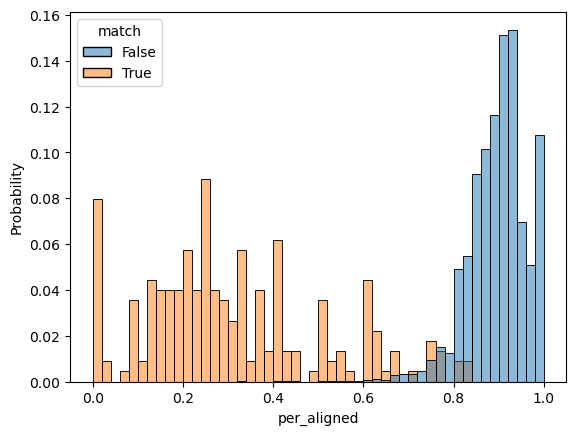

In [116]:
sns.histplot(data=data, x="per_aligned", hue="match", common_norm=False, stat="probability", bins=50)

<Axes: xlabel='per', ylabel='Probability'>

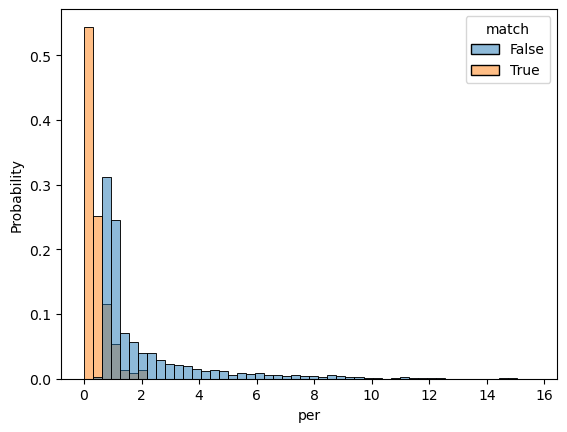

In [117]:
sns.histplot(data=data, x="per", hue="match", common_norm=False, stat="probability", bins=50)

<Axes: xlabel='dtw_score', ylabel='Probability'>

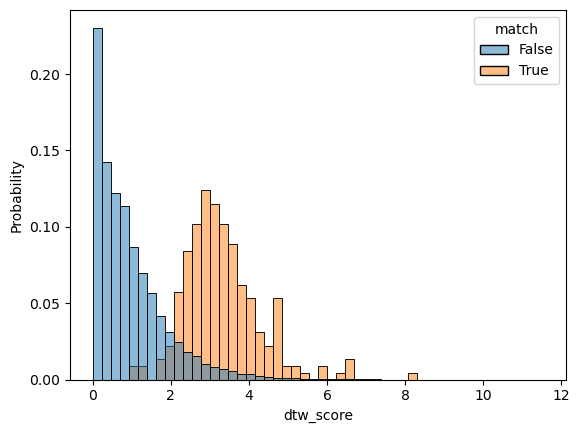

In [118]:
sns.histplot(data=data, x="dtw_score", hue="match", common_norm=False, stat="probability", bins=50)

In [119]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

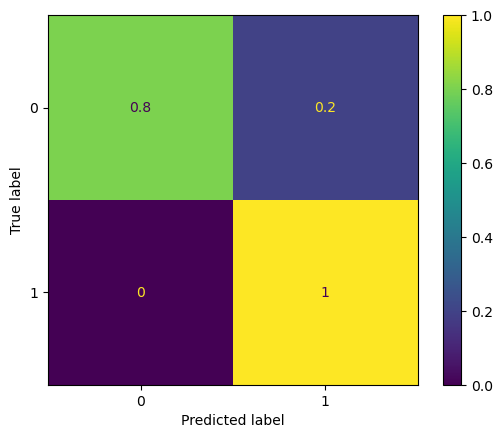

In [152]:
ConfusionMatrixDisplay(confusion_matrix(data.match, data.per_aligned < 0.85, normalize="true")).plot()

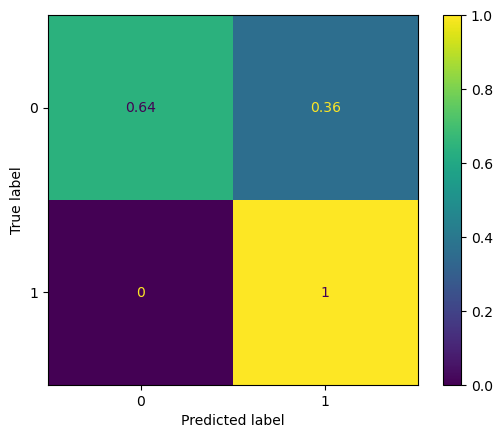

In [153]:
ConfusionMatrixDisplay(confusion_matrix(data.match, data.dtw_score > 1., normalize="true")).plot()

/Users/sebastien.wertz/micromamba/envs/flowchase/lib/python3.10/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/sebastien.wertz/micromamba/envs/flowchase/lib/python3.10/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/sebastien.wertz/micromamba/envs/flowchase/lib/python3.10/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/sebastien.wertz/micromamba/envs/flowchase/lib/python3.10/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and 

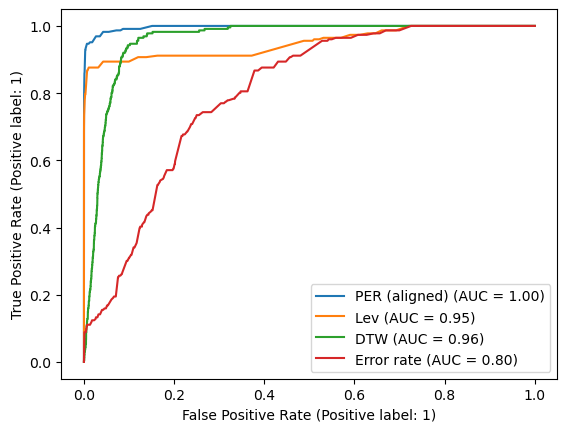

In [122]:
roc = RocCurveDisplay.from_predictions(data.match, -data.per_aligned, name="PER (aligned)");
RocCurveDisplay.from_predictions(data.match, -data.per, name="Lev", ax=roc.ax_);
RocCurveDisplay.from_predictions(data.match, data.dtw_score, name="DTW", ax=roc.ax_);

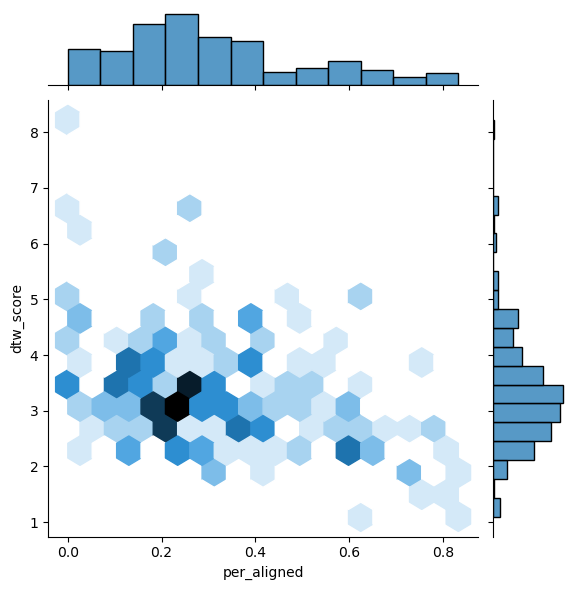

In [123]:
sns.jointplot(data[data.match], x="per_aligned", y="dtw_score", kind="hex")

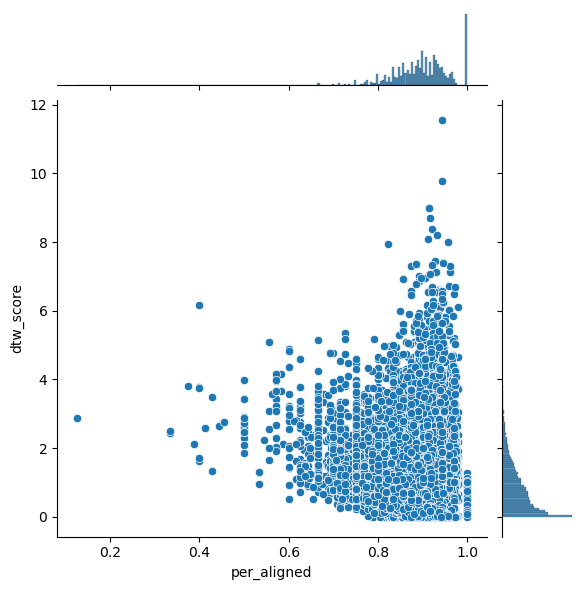

In [124]:
sns.jointplot(data[~data.match], x="per_aligned", y="dtw_score")

In [125]:
data[(data.per_aligned > 0.9) & (data.dtw_score > 9)].phonetics.unique()

array(['EH1_S|IY1|OW1 S_T_AE1_N_D_Z F_AO1_R S_ER1_CH EH1_N|JH_AH0_N AA2_P|T_AH0|M_AH0|S_EY1|SH_AH0_N'],
      dtype=object)

In [126]:
data[data.match & (data.per_aligned > 0.8)]

,error_rate,per_aligned,per,dtw_score,true_phonetics,phonetics,pred_phones,n_phones,n_words,match
12663,1.0,0.833333,1.0,1.097141,HH_AO1_L,HH_AO1_L,"[HH, AA, AH, NG]",3,1,True
22311,1.0,0.833333,1.0,1.748114,P_IH1_R,P_IH1_R,"[P, HH, EY, EH]",3,1,True
30351,1.0,0.812500,1.0,1.275375,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IY, D, HH, AE, CH, JH, D, IH, UH, D]",8,1,True


In [151]:
analyze(df[df.cmu_phonetics == "D_IH0|T_EH1_K|T_IH0_D"])

3it [00:03,  1.19s/it]


,error_rate,per_aligned,per,dtw_score,true_phonetics,phonetics,pred_phones,n_phones,n_words,match
0,1.000,0.812500,1.000,1.275375,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IY, D, HH, AE, CH, JH, D, IH, UH, D]",8,1,True
1,1.000,0.812500,1.000,1.275375,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IY, D, HH, AE, CH, JH, D, IH, UH, D]",8,1,True
2,1.000,0.812500,1.000,1.275375,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IY, D, HH, AE, CH, JH, D, IH, UH, D]",8,1,True
3,0.125,0.111111,0.125,2.828147,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IH, T, EH, K, SH, T, IH, D]",8,1,True
4,0.125,0.111111,0.125,2.828147,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IH, T, EH, K, SH, T, IH, D]",8,1,True
5,0.125,0.111111,0.125,2.828147,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IH, T, EH, K, SH, T, IH, D]",8,1,True
6,0.000,0.000000,0.000,2.562543,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IH, T, EH, K, T, IH, D]",8,1,True
7,0.000,0.000000,0.000,2.562543,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IH, T, EH, K, T, IH, D]",8,1,True
8,0.000,0.000000,0.000,2.562543,D_IH0|T_EH1_K|T_IH0_D,D_IH0|T_EH1_K|T_IH0_D,"[D, IH, T, EH, K, T, IH, D]",8,1,True


In [128]:
df[df.cmu_phonetics == "D_IH0|T_EH1_K|T_IH0_D"]

,phrase_id,target_phoneme,target_word_indexes,target_syllable_indexes,phonetic_variant,text,cmu_phonetics,pronounciation_guide,syllable_parts,stress_category,words,syllabified_words,cmu,gibberish,audio_file_url,gender
audio_id,,,,,,,,,,,,,,,,
1XY_GLCWxQ6Rt2les_Jvd,awrtrytbyq,None,None,None,None,detected,D_IH0|T_EH1_K|T_IH0_D,d_i|t_e_k|t_i_d,de|tec|ted,None,"[""detected""]","[""de|tec|ted""]","[""D_IH0|T_EH1_K|T_IH0_D""]","[""d_i|t_e_k|t_i_d""]",data/flwc-phrase-audios/F2/F2-342.mp3,FEMALE
Ims-Irv8Xxr8g7XrSmRpw,awrtrytbyq,None,None,None,None,detected,D_IH0|T_EH1_K|T_IH0_D,d_i|t_e_k|t_i_d,de|tec|ted,None,"[""detected""]","[""de|tec|ted""]","[""D_IH0|T_EH1_K|T_IH0_D""]","[""d_i|t_e_k|t_i_d""]",data/flwc-phrase-audios/M1/M1-342.mp3,MALE
xk7lz1VNnaDUsTuqMSSDj,awrtrytbyq,None,None,None,None,detected,D_IH0|T_EH1_K|T_IH0_D,d_i|t_e_k|t_i_d,de|tec|ted,None,"[""detected""]","[""de|tec|ted""]","[""D_IH0|T_EH1_K|T_IH0_D""]","[""d_i|t_e_k|t_i_d""]",data/flwc-phrase-audios/F1/F1-342.mp3,FEMALE


In [129]:
df[df.cmu_phonetics == "B_EY1|B_IY0"]

,phrase_id,target_phoneme,target_word_indexes,target_syllable_indexes,phonetic_variant,text,cmu_phonetics,pronounciation_guide,syllable_parts,stress_category,words,syllabified_words,cmu,gibberish,audio_file_url,gender
audio_id,,,,,,,,,,,,,,,,
24YwmNnQvett7kcyIWPR3,cskjbfjcsn,None,None,None,None,baby,B_EY1|B_IY0,b_ey|b_ee,ba|by,None,"[""baby""]","[""ba|by""]","[""B_EY1|B_IY0""]","[""b_ey|b_ee""]",data/flwc-phrase-audios/F2/F2-174.mp3,FEMALE
Jhm6-fUfMAEGebXrKzvQ7,cskjbfjcsn,None,None,None,None,baby,B_EY1|B_IY0,b_ey|b_ee,ba|by,None,"[""baby""]","[""ba|by""]","[""B_EY1|B_IY0""]","[""b_ey|b_ee""]",data/flwc-phrase-audios/M1/M1-174.mp3,MALE
jIHVhfl2ZZ88mjkJozI-2,cskjbfjcsn,None,None,None,None,baby,B_EY1|B_IY0,b_ey|b_ee,ba|by,None,"[""baby""]","[""ba|by""]","[""B_EY1|B_IY0""]","[""b_ey|b_ee""]",data/flwc-phrase-audios/F1/F1-174.mp3,FEMALE


In [130]:
analyze(df[df.cmu_phonetics == "B_EY1|B_IY0"])

3it [00:00,  3.11it/s]


,error_rate,per_aligned,per,dtw_score,true_phonetics,phonetics,pred_phones,n_phones,n_words,match
0,0.50,0.333333,0.50,5.395589,B_EY1|B_IY0,B_EY1|B_IY0,"[B, EY, Y, B, IY, HH]",4,1,True
1,0.50,0.333333,0.50,5.395589,B_EY1|B_IY0,B_EY1|B_IY0,"[B, EY, Y, B, IY, HH]",4,1,True
2,0.50,0.333333,0.50,5.395589,B_EY1|B_IY0,B_EY1|B_IY0,"[B, EY, Y, B, IY, HH]",4,1,True
3,1.50,0.800000,1.50,2.325324,B_EY1|B_IY0,B_EY1|B_IY0,"[P, EY, N, Y, IY, P, IY, HH]",4,1,True
4,1.50,0.800000,1.50,2.325324,B_EY1|B_IY0,B_EY1|B_IY0,"[P, EY, N, Y, IY, P, IY, HH]",4,1,True
5,1.50,0.800000,1.50,2.325324,B_EY1|B_IY0,B_EY1|B_IY0,"[P, EY, N, Y, IY, P, IY, HH]",4,1,True
6,0.75,0.428571,0.75,3.851438,B_EY1|B_IY0,B_EY1|B_IY0,"[B, EY, IY, EY, IY, B, IY]",4,1,True
7,0.75,0.428571,0.75,3.851438,B_EY1|B_IY0,B_EY1|B_IY0,"[B, EY, IY, EY, IY, B, IY]",4,1,True
8,0.75,0.428571,0.75,3.851438,B_EY1|B_IY0,B_EY1|B_IY0,"[B, EY, IY, EY, IY, B, IY]",4,1,True


In [131]:
s, fs = read_audio_file("data/flwc-phrase-audios/M1/M1-174.mp3", fs=16000)

phonetics = "B_EY1|B_IY0"
phone_prob_matrix = model.predict_phone_prob_matrix(s, 16000)

(
    max_posterior_df,
    max_posterior_df_filtered_processed,
    max_posterior_df_filtered_processed_threshed,
) = model.max_posterior_phone_df(phone_prob_matrix, proba_thresh=0.5)
pred_phoneme_list = max_posterior_df_filtered_processed_threshed.phone.tolist()

In [132]:
max_posterior_df_filtered_processed_threshed

,phone,n_frames,max_proba,mean_proba
0,P,1,0.797062,0.797062
1,EY,1,0.799949,0.799949
2,N,2,0.803345,0.652555
3,Y,3,1.000000,0.800042
4,IY,3,1.000000,0.767810
5,P,4,1.000000,0.722684
6,IY,7,1.000000,0.238019
7,HH,2,0.609130,0.508153


In [133]:
RESA

['P', '-', 'EY', 'N', 'Y', 'IY', 'P', '-', 'IY', 'HH']

In [134]:
play_audio("data/flwc-phrase-audios/M1/M1-174.mp3")

In [135]:
recorder = record_audio(); recorder

AudioRecorder(audio=Audio(value=b'', format='webm'), stream=CameraStream(constraints={'audio': True, 'video': …

In [145]:
sig, sr = get_recording(recorder)

In [146]:
phone_prob_matrix = model.predict_phone_prob_matrix(sig, sr)
(
    max_posterior_df,
    max_posterior_df_filtered_processed,
    max_posterior_df_filtered_processed_threshed,
) = model.max_posterior_phone_df(phone_prob_matrix, proba_thresh=0.5)
pred_phoneme_list = max_posterior_df_filtered_processed_threshed.phone.tolist()

In [147]:
max_posterior_df_filtered_processed_threshed

,phone,n_frames,max_proba,mean_proba
0,B,2,1.0,0.948456
1,EY,5,1.0,0.875743
2,B,4,1.0,0.752440
3,IY,6,1.0,0.786978


In [148]:
pred_phoneme_list

['B', 'EY', 'B', 'IY']

In [149]:
RESA, RESB = list_pairwise_alignment(pred_phoneme_list, ["B", "EY", "B", "IY"])
_, _, _, _, per_aligned = calculate_phoneme_errors(RESB, RESA)

In [150]:
per_aligned

0.0